In [2]:
from dotenv import load_dotenv
import os
load_dotenv("../.env") 
MONGO_URI = os.getenv("MONGO_URI")
from pymongo import MongoClient
import pandas as pd
client = MongoClient(MONGO_URI)
db = client["veille_media"]
collection = db["articles"]
data = list(collection.find())
df = pd.DataFrame(data)

df.head()

,_id,id_article,source,titre,date_publication,contenu,url,categorie,sentiment,source_type,created_at,sentiment_score,langue
0,696f6450803a3bd1d5076f9f,https://www.madagascar-tribune.com/Conjoncture...,https://www.madagascar-tribune.com/spip.php?pa...,Richard Ravalomanana et Marie Michelle Sahondr...,2026-01-20 05:36:32,Deux figures emblématiques du régime Rajoelina...,https://www.madagascar-tribune.com/Conjoncture...,[politique],neutre,rss,2026-01-20 05:36:32,-0.010000,fr
1,696f6450803a3bd1d5076fa0,https://www.madagascar-tribune.com/Senat-la-HC...,https://www.madagascar-tribune.com/spip.php?pa...,Sénat : la HCC confirme la fin du mandat et l'...,2026-01-20 05:31:21,La Haute Cour constitutionnelle (HCC) a offici...,https://www.madagascar-tribune.com/Senat-la-HC...,[politique],positif,rss,2026-01-20 05:31:21,0.117500,fr
2,696f6451803a3bd1d5076fa1,https://www.madagascar-tribune.com/103-signatu...,https://www.madagascar-tribune.com/spip.php?pa...,103 poids plume,2026-01-19 05:35:00,Lors d'« Assises des Partis Politiques » pour ...,https://www.madagascar-tribune.com/103-signatu...,[autre],neutre,rss,2026-01-19 05:35:00,-0.013636,fr
3,696f6451803a3bd1d5076fa2,https://www.madagascar-tribune.com/Concertatio...,https://www.madagascar-tribune.com/spip.php?pa...,Concertation nationale : le président de la Re...,2026-01-19 05:00:00,Le colonel Randrianarina est venu à la rescous...,https://www.madagascar-tribune.com/Concertatio...,[politique],positif,rss,2026-01-19 05:00:00,0.102857,fr
4,696f6451803a3bd1d5076fa3,https://www.madagascar-tribune.com/Administrat...,https://www.madagascar-tribune.com/spip.php?pa...,Herintsalama Rajaonarivelo ferme la porte à un...,2026-01-19 04:00:00,"Ce dimanche, devant des milliers de fidèles de...",https://www.madagascar-tribune.com/Administrat...,"[politique, international]",neutre,rss,2026-01-19 04:00:00,0.091111,fr


In [3]:
print("Total articles:", len(df))
print(df.info())
print(df.isna().sum())
lignes_vides = df[df.isin(["VIDE"]).any(axis=1)]
print("Nombre de lignes avec au moins un contenu vide :", len(lignes_vides))
lignes_vides

Total articles: 1963
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1963 entries, 0 to 1962
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   _id               1963 non-null   object        
 1   id_article        1963 non-null   object        
 2   source            1963 non-null   object        
 3   titre             1963 non-null   object        
 4   date_publication  1963 non-null   datetime64[ns]
 5   contenu           1963 non-null   object        
 6   url               1963 non-null   object        
 7   categorie         1963 non-null   object        
 8   sentiment         1963 non-null   object        
 9   source_type       1963 non-null   object        
 10  created_at        1963 non-null   object        
 11  sentiment_score   1963 non-null   float64       
 12  langue            1963 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(11)
memory usage

,_id,id_article,source,titre,date_publication,contenu,url,categorie,sentiment,source_type,created_at,sentiment_score,langue


In [4]:
from collections import Counter
types = Counter()

for doc in collection.find({}, {"date_publication": 1}):
    value = doc.get("date_publication")
    types[type(value).__name__] += 1

print(types)

Counter({'datetime': 1963})


In [7]:
for doc in collection.find({}, {"date_publication": 1, "titre": 1, "source_type": 1}):
    if isinstance(doc.get("date_publication"), str):
        print(doc)

In [8]:
for doc in collection.find({}, {"date_publication": 1, "titre": 1, "source_type": 1}):
    if not isinstance(doc.get("date_publication"), str):
        print(doc)

{'_id': ObjectId('696f6450803a3bd1d5076f9f'), 'titre': 'Richard Ravalomanana et Marie Michelle Sahondraharimalala en détention préventive', 'date_publication': datetime.datetime(2026, 1, 20, 5, 36, 32), 'source_type': 'rss'}
{'_id': ObjectId('696f6450803a3bd1d5076fa0'), 'titre': "Sénat : la HCC confirme la fin du mandat et l'impossibilité de toute prorogation", 'date_publication': datetime.datetime(2026, 1, 20, 5, 31, 21), 'source_type': 'rss'}
{'_id': ObjectId('696f6451803a3bd1d5076fa1'), 'titre': '103 poids plume', 'date_publication': datetime.datetime(2026, 1, 19, 5, 35), 'source_type': 'rss'}
{'_id': ObjectId('696f6451803a3bd1d5076fa2'), 'titre': 'Concertation nationale : le président de la Refondation défend le FFKM', 'date_publication': datetime.datetime(2026, 1, 19, 5, 0), 'source_type': 'rss'}
{'_id': ObjectId('696f6451803a3bd1d5076fa3'), 'titre': 'Herintsalama Rajaonarivelo ferme la porte à une transition prolongée', 'date_publication': datetime.datetime(2026, 1, 19, 4, 0), 's

In [7]:
from dateutil import parser
from datetime import datetime

for doc in collection.find({"date_publication": {"$type": "string"}}):
    try:
        new_date = parser.parse(doc["date_publication"])
        
        collection.update_one(
            {"_id": doc["_id"]},
            {"$set": {"date_publication": new_date}}
        )
    except Exception as e:
        print(f"Erreur sur {doc['_id']} : {doc['date_publication']}")


In [14]:
from datetime import datetime

def normalize_date(date_str):
    if not date_str:
        return None
    
    cleaned = date_str.replace("Date:", "").strip()
    
    try:
        return datetime.strptime(cleaned, "%d/%m/%Y")
    except:
        return None


for doc in collection.find():
    
    date_pub = doc.get("date_publication")
    created = doc.get("created_at")
    
    new_date = None
    
    # 1️⃣ Si déjà datetime
    if isinstance(date_pub, datetime):
        continue
    
    # 2️⃣ Si string → essayer conversion
    if isinstance(date_pub, str):
        new_date = normalize_date(date_pub)
    
    # 3️⃣ Si vide ou conversion échoue → fallback created_at
    if not new_date:
        if isinstance(created, datetime):
            new_date = created
    
    # 4️⃣ Update si on a trouvé une date
    if new_date:
        collection.update_one(
            {"_id": doc["_id"]},
            {"$set": {"date_publication": new_date}}
        )
    else:
        print(f"Aucune date valide pour {doc['_id']}")


In [9]:
from bson import ObjectId

for doc in collection.find({
    "date_publication": None
}):
    
    object_date = doc["_id"].generation_time
    
    collection.update_one(
        {"_id": doc["_id"]},
        {"$set": {"date_publication": object_date}}
    )


In [4]:
result = collection.aggregate([
    {"$group": {"_id": {"$type": "$date_publication"}, "count": {"$sum": 1}}}
])

for r in result:
    print(r)


{'_id': 'date', 'count': 1963}


In [16]:
doc = collection.find_one(
    {"date_publication": {"$type": "string"}},
    {"date_publication": 1}
)

print(doc)


None


In [15]:
collection.delete_many({
    "$or": [
        {"contenu": ""},
        {"contenu": None},
        {"contenu": {"$regex": r"^\s*$"}}
    ]
})


DeleteResult({'n': 0, 'electionId': ObjectId('7fffffff000000000000003d'), 'opTime': {'ts': Timestamp(1772108538, 1), 't': 61}, 'ok': 1.0, '$clusterTime': {'clusterTime': Timestamp(1772108538, 1), 'signature': {'hash': b'>\xa7\x91\x16:\xfc(\x1f\xc9|T\xa7\x14\xc2\xe4\xec\x88\x83\xb9\x0c', 'keyId': 7573748671250956292}}, 'operationTime': Timestamp(1772108538, 1)}, acknowledged=True)

In [16]:
collection.delete_many({
    "$or": [
        {"titre": ""},
        {"titre": None},
        {"titre": {"$regex": r"^\s*$"}}
    ]
})


DeleteResult({'n': 1, 'electionId': ObjectId('7fffffff000000000000003d'), 'opTime': {'ts': Timestamp(1772108578, 2), 't': 61}, 'ok': 1.0, '$clusterTime': {'clusterTime': Timestamp(1772108578, 2), 'signature': {'hash': b'\xf2\xa9\xbds\x81\xb7\x81\xd8$#st\x1e,\x8b\xa1\xae\xf0=V', 'keyId': 7573748671250956292}}, 'operationTime': Timestamp(1772108578, 2)}, acknowledged=True)

In [31]:
from pymongo import UpdateOne

# Listes de référence
RSS_FEEDS = [
    "https://www.madagascar-tribune.com/spip.php?page=backend",
    "https://www.lexpress.mg/feeds/posts/default",
    "https://newsmada.com/feed/",
    "https://midi-madagasikara.mg/feed/",  
    "https://2424.mg/feed/",
    "https://rsf.org/fr/rss/afrique/madagascar/feed.xml",
    "https://www.madagate.org/index.php?format=feed&type=rss",
    "https://lgdi-madagascar.com/feed/",
    "https://midi-madagasikara.mg/category/politique/feed/",
    "https://midi-madagasikara.mg/category/economie/feed/",
    "https://www.lexpress.mg/feeds/posts/default/-/Politique",
    "https://www.lexpress.mg/feeds/posts/default/-/%C3%89conomie",
    "https://newsmada.com/category/les-nouvelles/feed/",
    "https://newsmada.com/category/les-nouvelles/politique/feed/",
    "https://2424.mg/category/actualite/politique/feed/",
    "https://2424.mg/category/actualite/economie/feed/",
    "https://www.lemonde.fr/madagascar/rss_full.xml",
    "https://www.courrierinternational.com/feed/rubrique/madagascar/rss.xml",
    "https://news.google.com/rss/search?q=Madagascar&hl=fr&gl=FR&ceid=FR:fr",
    "https://tanikomadagascar.com/feed/",
    "https://namana-studio.fr/feed/",
    "https://www.youtube.com/feeds/videos.xml?channel_id=UCK84qSI2bEMWkX9vUptkAlA"
]

SCRAP_HTML_SOURCES = ["Malagasy News"]
SCRAP_SELENIUM_SOURCES = ["Orange Actu"]

operations = []

# Parcourir uniquement les docs où source_type est vide ou None
for doc in collection.find({"$or": [{"source_type": {"$exists": False}}, {"source_type": None}, {"source_type": ""}]}):
    source = (doc.get("source") or "").strip()
    source_type = None

    # Vérifier RSS
    if any(source.startswith(rss) for rss in RSS_FEEDS):
        source_type = "rss"
    # Vérifier SCRAP_HTML
    elif any(source.startswith(scrap) for scrap in SCRAP_HTML_SOURCES):
        source_type = "scrap_html"
    # Vérifier SCRAP_SELENIUM
    elif any(scrap in source for scrap in SCRAP_SELENIUM_SOURCES):
        source_type = "scrap_selenium"
    # fallback
    else:
        source_type = "inconnu"

    operations.append(
        UpdateOne(
            {"_id": doc["_id"]},
            {"$set": {"source_type": source_type}}
        )
    )

# Exécution batch
if operations:
    result = collection.bulk_write(operations)
    print(f"Documents mis à jour avec source_type : {result.modified_count}")
else:
    print("Aucun document vide à mettre à jour")



Aucun document vide à mettre à jour


In [10]:
result = collection.aggregate([
    {"$group": {"_id": "$source_type", "count": {"$sum": 1}}}
])

for r in result:
    print(r)

{'_id': 'rss', 'count': 1868}
{'_id': 'scrap_html', 'count': 27}
{'_id': 'scrap_selenium', 'count': 68}


In [19]:
from pymongo import MongoClient
import pandas as pd
client = MongoClient(MONGO_URI)
db = client["veille_media"]
collection = db["articles"]
data = list(collection.find())
df = pd.DataFrame(data)

df.head()

,_id,id_article,source,titre,date_publication,contenu,url,categorie,sentiment,source_type,created_at,sentiment_score,langue
0,696f6450803a3bd1d5076f9f,https://www.madagascar-tribune.com/Conjoncture...,https://www.madagascar-tribune.com/spip.php?pa...,Richard Ravalomanana et Marie Michelle Sahondr...,2026-01-20 05:36:32,Deux figures emblématiques du régime Rajoelina...,https://www.madagascar-tribune.com/Conjoncture...,[politique],neutre,rss,2026-01-20 05:36:32,0.05000,fr
1,696f6450803a3bd1d5076fa0,https://www.madagascar-tribune.com/Senat-la-HC...,https://www.madagascar-tribune.com/spip.php?pa...,Sénat : la HCC confirme la fin du mandat et l'...,2026-01-20 05:31:21,La Haute Cour constitutionnelle (HCC) a offici...,https://www.madagascar-tribune.com/Senat-la-HC...,[politique],neutre,rss,2026-01-20 05:31:21,0.19375,fr
2,696f6451803a3bd1d5076fa1,https://www.madagascar-tribune.com/103-signatu...,https://www.madagascar-tribune.com/spip.php?pa...,103 poids plume,2026-01-19 05:35:00,Lors d'« Assises des Partis Politiques » pour ...,https://www.madagascar-tribune.com/103-signatu...,[autre],negatif,rss,2026-01-19 05:35:00,-0.40000,fr
3,696f6451803a3bd1d5076fa2,https://www.madagascar-tribune.com/Concertatio...,https://www.madagascar-tribune.com/spip.php?pa...,Concertation nationale : le président de la Re...,2026-01-19 05:00:00,Le colonel Randrianarina est venu à la rescous...,https://www.madagascar-tribune.com/Concertatio...,[politique],neutre,rss,2026-01-19 05:00:00,0.20000,fr
4,696f6451803a3bd1d5076fa3,https://www.madagascar-tribune.com/Administrat...,https://www.madagascar-tribune.com/spip.php?pa...,Herintsalama Rajaonarivelo ferme la porte à un...,2026-01-19 04:00:00,"Ce dimanche, devant des milliers de fidèles de...",https://www.madagascar-tribune.com/Administrat...,[politique],neutre,rss,2026-01-19 04:00:00,0.00000,fr


In [33]:
from pymongo import UpdateOne

operations = []

# Parcourir uniquement les documents où created_at est vide ou None
for doc in collection.find({"$or": [{"created_at": {"$exists": False}}, {"created_at": None}, {"created_at": ""}]}):
    date_pub = doc.get("date_publication")
    
    if date_pub:  # on ne copie que si date_publication existe
        operations.append(
            UpdateOne(
                {"_id": doc["_id"]},
                {"$set": {"created_at": date_pub}}
            )
        )

# Exécution batch
if operations:
    result = collection.bulk_write(operations)
    print(f"Documents mis à jour avec created_at : {result.modified_count}")
else:
    print("Aucun document vide à mettre à jour")


Aucun document vide à mettre à jour


In [34]:
result = collection.aggregate([
     {"$group": {"_id": "$created_at", "count": {"$sum": 1}}}
])

for r in result:
    print(r)

{'_id': datetime.datetime(2026, 1, 23, 2, 35, 0, 1000), 'count': 1}
{'_id': datetime.datetime(2026, 1, 14, 5, 25, 15), 'count': 1}
{'_id': datetime.datetime(2026, 1, 21, 6, 11), 'count': 1}
{'_id': '2026-02-12T16:31:14.559270', 'count': 1}
{'_id': datetime.datetime(2026, 1, 20, 2, 40), 'count': 1}
{'_id': '2026-02-12T16:31:14.561559', 'count': 1}
{'_id': '2026-02-19T09:48:40.690298', 'count': 1}
{'_id': datetime.datetime(2025, 12, 31, 13, 0, 10), 'count': 1}
{'_id': '2026-02-17T08:35:33.616503', 'count': 1}
{'_id': '2026-02-16T15:12:45.493555', 'count': 1}
{'_id': datetime.datetime(2025, 12, 8, 9, 10, 14), 'count': 1}
{'_id': '2026-02-17T08:36:33.058392', 'count': 1}
{'_id': '2026-02-13T08:41:48.346899', 'count': 1}
{'_id': '2026-02-17T08:46:55.691282', 'count': 1}
{'_id': datetime.datetime(2026, 1, 27, 19, 2, 15), 'count': 1}
{'_id': datetime.datetime(2026, 1, 22, 4, 41, 43), 'count': 1}
{'_id': datetime.datetime(2026, 1, 27, 2, 50, 0, 1000), 'count': 1}
{'_id': datetime.datetime(2026

In [12]:
print(df["date_publication"].dtype)
df["date_publication"].head()

object


0    2026-01-20 05:36:32
1    2026-01-20 05:31:21
2    2026-01-19 05:35:00
3    2026-01-19 05:00:00
4    2026-01-19 04:00:00
Name: date_publication, dtype: object

In [20]:
import pandas as pd

df["date_publication"] = pd.to_datetime(
    df["date_publication"],
    errors="coerce"
)

print(df["date_publication"].dtype)
print("NaT :", df["date_publication"].isna().sum())

object
NaT : 0


C:\Users\nombaina\AppData\Local\Temp\ipykernel_15436\3520933027.py:3: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["date_publication"] = pd.to_datetime(


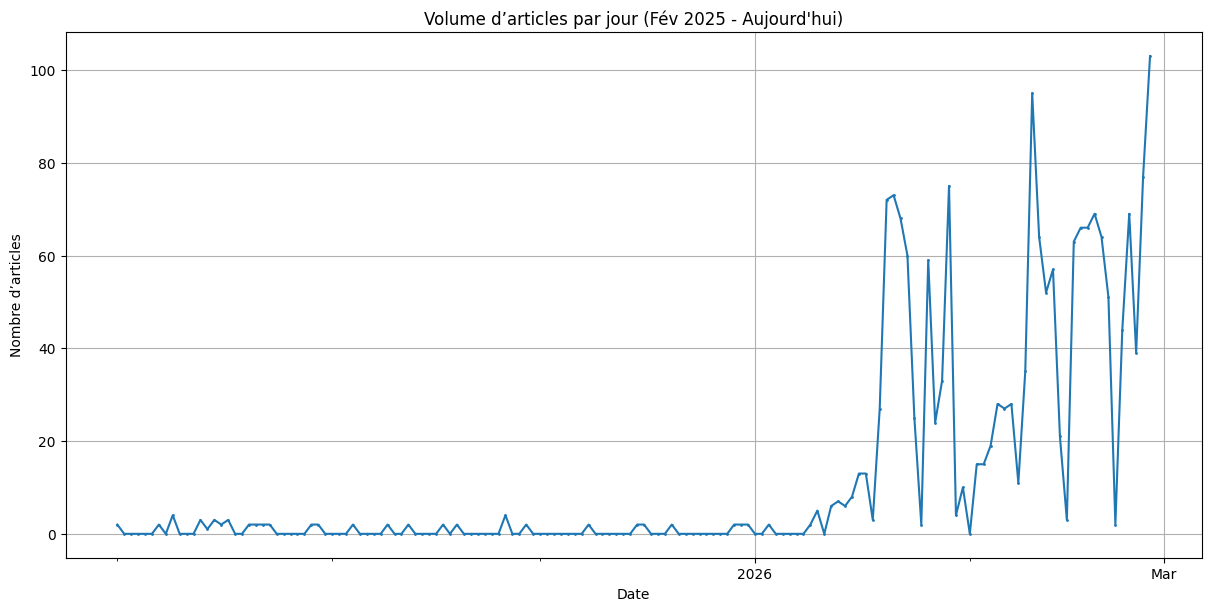

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Assurer que date_publication est datetime UTC
df["date_publication"] = pd.to_datetime(df["date_publication"], errors="coerce", utc=True)

# Filtrer à partir du 1er février 2025
start_date = pd.Timestamp("2025-10-01", tz="UTC")
end_date = pd.Timestamp.now(tz="UTC")
df_filtre = df[df["date_publication"] >= start_date]

# Grouper par jour
volume_jour = df_filtre.groupby(df_filtre["date_publication"].dt.normalize()).size()

# Reindex pour inclure tous les jours jusqu'à aujourd'hui
all_dates = pd.date_range(start=start_date, end=end_date, freq="D", tz="UTC")
volume_jour = volume_jour.reindex(all_dates, fill_value=0)

# --- Création du graphique ---
fig, ax = plt.subplots(figsize=(12,6), layout='constrained')

ax.plot(volume_jour.index, volume_jour.values, marker='o', markersize=1, linestyle='-')

# Major ticks every 6 months, minor ticks every month
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1,3)))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

# Utilisation d'un ConciseDateFormatter pour plus de clarté
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.set_title("Volume d’articles par jour (Fév 2025 - Aujourd'hui)")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre d’articles")
ax.grid(True)

plt.show()

In [10]:
df = pd.DataFrame(list(collection.find()))
print(df["categorie"].head())

0                   [politique]
1          [politique, justice]
2    [politique, international]
3                   [politique]
4                       [autre]
Name: categorie, dtype: object


In [11]:
df_exploded = df.explode("categorie")
print(df_exploded["categorie"].head())

0        politique
1        politique
1          justice
2        politique
2    international
Name: categorie, dtype: object


In [16]:
df_exploded.head()

,_id,id_article,source,titre,date_publication,contenu,url,categorie,sentiment,source_type,created_at,sentiment_score,langue
0,696f6450803a3bd1d5076f9f,https://www.madagascar-tribune.com/Conjoncture...,https://www.madagascar-tribune.com/spip.php?pa...,Richard Ravalomanana et Marie Michelle Sahondr...,2026-01-20 05:36:32,Deux figures emblématiques du régime Rajoelina...,https://www.madagascar-tribune.com/Conjoncture...,politique,neutre,rss,2026-01-20 05:36:32,0.05000,fr
1,696f6450803a3bd1d5076fa0,https://www.madagascar-tribune.com/Senat-la-HC...,https://www.madagascar-tribune.com/spip.php?pa...,Sénat : la HCC confirme la fin du mandat et l'...,2026-01-20 05:31:21,La Haute Cour constitutionnelle (HCC) a offici...,https://www.madagascar-tribune.com/Senat-la-HC...,politique,neutre,rss,2026-01-20 05:31:21,0.19375,fr
2,696f6451803a3bd1d5076fa1,https://www.madagascar-tribune.com/103-signatu...,https://www.madagascar-tribune.com/spip.php?pa...,103 poids plume,2026-01-19 05:35:00,Lors d'« Assises des Partis Politiques » pour ...,https://www.madagascar-tribune.com/103-signatu...,autre,negatif,rss,2026-01-19 05:35:00,-0.40000,fr
3,696f6451803a3bd1d5076fa2,https://www.madagascar-tribune.com/Concertatio...,https://www.madagascar-tribune.com/spip.php?pa...,Concertation nationale : le président de la Re...,2026-01-19 05:00:00,Le colonel Randrianarina est venu à la rescous...,https://www.madagascar-tribune.com/Concertatio...,politique,neutre,rss,2026-01-19 05:00:00,0.20000,fr
4,696f6451803a3bd1d5076fa3,https://www.madagascar-tribune.com/Administrat...,https://www.madagascar-tribune.com/spip.php?pa...,Herintsalama Rajaonarivelo ferme la porte à un...,2026-01-19 04:00:00,"Ce dimanche, devant des milliers de fidèles de...",https://www.madagascar-tribune.com/Administrat...,politique,neutre,rss,2026-01-19 04:00:00,0.00000,fr


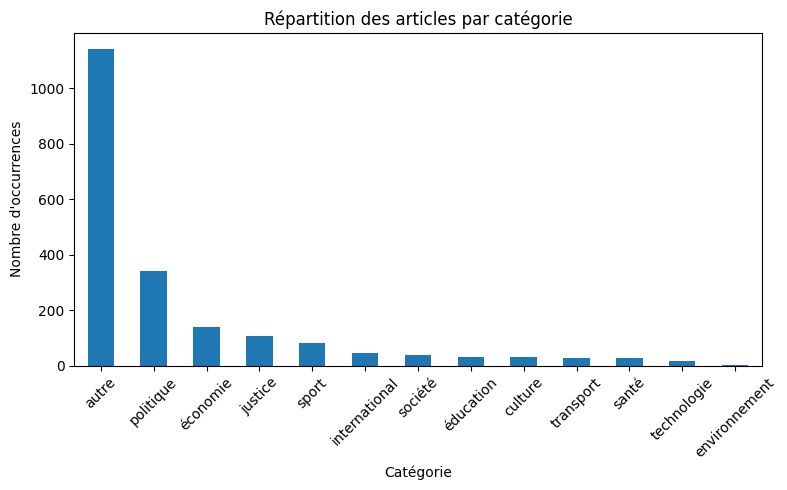

In [12]:
import matplotlib.pyplot as plt

volume_cat = df_exploded["categorie"].value_counts()

plt.figure(figsize=(8,5))
volume_cat.plot(kind="bar")

plt.title("Répartition des articles par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Nombre d'occurrences")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
result = collection.delete_many({
     "source": "https://tanikomadagascar.com/feed/"
})

print("Nombre d'articles supprimés :", result.deleted_count)

Nombre d'articles supprimés : 68


In [7]:
import re
import unicodedata
from bs4 import BeautifulSoup
from langdetect import detect, DetectorFactory
from textblob import Blobber
from textblob_fr import PatternTagger, PatternAnalyzer
from sentence_transformers import SentenceTransformer, util
import torch
from collections import Counter

DetectorFactory.seed = 0
tb_fr = Blobber(pos_tagger=PatternTagger(), analyzer=PatternAnalyzer())

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

malagasy_words = {
    # ===== PRONOMS & MOTS COURANTS =====
    "izy", "anao", "aho", "isika", "ianao", "izy ireo", "izany", "ity", "ireo",
    "eto", "any", "amin", "amin'ny", "ao", "ary", "na", "fa", "raha", "satria",

    # ===== SOCIETE / ADMINISTRATION =====
    "firenena", "tanora", "mponina", "sekoly", "mpianatra",
    "governemanta", "ministera", "ben'ny tanàna", "ben ny tanana",
    "depiote", "depute", "filoha", "antoko politika",
    "lalàm-panorenana", "lalampanorenana",
    "repoblika", "kaominina", "prefe", "distrika",
    "mpitondra", "fitondrana", "biraom-panjakana",

    # ===== VIE QUOTIDIENNE =====
    "trano", "làlana", "lalana", "fianakaviana",
    "asa", "vidim-piainana", "vidimpiainana",
    "fampandrosoana", "fiainana", "vahoaka",
    "zaza", "reny", "ray",

    # ===== ECONOMIE / COMMERCE =====
    "toekarena", "varotra", "orinasa", "tsena",
    "banky", "fampiasam-bola", "fampiasambola",
    "hetra", "karama", "vola", "tetibola",
    "fividianana", "fanondranana", "fanondranana entana",

    # ===== SANTE =====
    "fahasalamana", "hopitaly", "hôpitaly",
    "dokoterà", "dokotera", "aretina",
    "vaksiny", "fanafody", "marary",
    "valanaretina", "hopital",

    # ===== EDUCATION =====
    "fanabeazana", "oniversite", "universite",
    "mpampianatra", "kilasy", "sekoly ambony",
    "mpianatra", "fampianarana",

    # ===== SPORT =====
    "baolina kitra", "lalao", "ekipa",
    "fifaninanana", "mpilalao", "stadiona",

    # ===== TECHNOLOGIE =====
    "haitao", "siansa", "fikajiana",
    "rindranasa", "aterineto", "tambajotra",
    "finday", "solosaina",

    # ===== ENVIRONNEMENT =====
    "tontolo iainana", "toetrandro",
    "fandotoana", "ala", "rano",
    "rivodoza", "hain-tany",

    # ===== INTERNATIONAL =====
    "iraisam-pirenena", "ady",
    "fifandraisana iraisam-pirenena",
    "firaisankina", "diplomasia",

    # ===== JUSTICE =====
    "heloka", "fitsarana",
    "mpisolovava", "polisy",
    "fonja", "lalàna", "lalana",

    # ===== TRANSPORT =====
    "fitaterana", "seranam-piaramanidina",
    "taxi-be", "taxibe",
    "bus", "fiara", "sambo",

    # ===== MEDIAS / ACTUALITE =====
    "vaovao", "gazety", "fampitam-baovao",
    "mpanao gazety", "tatitra",
    "fanambarana", "lahateny"
}


def clean_text(html_text: str) -> str:
    """Nettoie le HTML pour ne garder que le texte brut."""
    if not html_text:
        return ""
    soup = BeautifulSoup(html_text, "html.parser")
    text = soup.get_text(separator=" ")
    text = unicodedata.normalize("NFKC", text)
    return " ".join(text.split())

def normalize_text(text: str) -> str:
    if not text:
        return ""

    soup = BeautifulSoup(text, "html.parser")
    text = text.lower()
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")
    text = re.sub(r"[^\w\s]", " ", text)
    return " ".join(text.split())

malagasy_words_set = set(malagasy_words)
malagasy_expr = [normalize_text(expr) for expr in malagasy_words if " " in expr]

_lang_cache = {}
    
def detect_language(text: str, min_mg_words: int = 2) -> str:
    if not text:
        return "unknown"

    if text in _lang_cache:
        return _lang_cache[text]

    clean = normalize_text(text)
    words = clean.split()

    mg_count = sum(1 for w in words if w in malagasy_words_set)

    if mg_count >= min_mg_words:
        _lang_cache[text] = "mg"
        return "mg"

    try:
        lang = detect(text)
        _lang_cache[text] = lang if lang in ["fr", "mg"] else "other"
        return _lang_cache[text]
    except:
        _lang_cache[text] = "unknown"
        return "unknown"
        
_sentiment_cache = {}

def analyze_sentiment_score(text: str) -> float:
    if not text:
        return 0.0

    if text in _sentiment_cache:
        return _sentiment_cache[text]

    lang = detect_language(text)

    if lang == "fr":
        score = float(tb_fr(text).sentiment[0])
    else:
        score = 0.0

    _sentiment_cache[text] = score
    return score

def analyze_sentiment(text: str) -> str:
    score = analyze_sentiment_score(text)
    if score > 0.1:
        return "positif"
    elif score < -0.1:
        return "negatif"
    return "neutre"

keywords_map = {

    "politique": [
        # FR fort
        "président", "premier ministre", "gouvernement", "député",
        "sénat", "assemblée nationale", "élection", "campagne",
        "parti", "opposition", "majorité", "constitution",
        "république", "mandat", "candidat", "ministre",
        "manifestation", "coup d etat",

        # MG fort
        "filoha", "governemanta", "ministera", "depiote",
        "fifidianana", "antoko politika", "lalampanorenana",
        "repoblika"
    ],

    "justice": [
        "tribunal", "juge", "procureur", "cour",
        "justice", "avocat", "condamnation", "détention",
        "prison", "garde a vue", "incarcération",
        "crime", "enquête", "police", "gendarmerie",

        "fitsarana", "mpisolovava", "heloka",
        "fanadihadiana", "polisy"
    ],

    "économie": [
        "économie", "inflation", "croissance",
        "budget", "finance", "banque", "investissement",
        "marché", "entreprise", "industrie", "exportation",

        "toekarena", "varotra", "orinasa",
        "tsena", "fampiasambola"
    ],

    "société": [
        "population", "citoyen", "communauté",
        "social", "pauvreté", "emploi",
        "sécurité", "migration",

        "mponina", "fiarahamonina",
        "tanora", "fianakaviana"
    ],

    "santé": [
        "hôpital", "médecin", "maladie",
        "vaccin", "urgence", "épidémie",
        "santé publique",

        "hopitaly", "dokoterà",
        "aretina", "fahasalamana"
    ],

    "éducation": [
        "école", "université", "enseignement",
        "étudiant", "professeur", "examen",
        "réforme scolaire",

        "sekoly", "oniversite",
        "fanabeazana", "mpianatra"
    ],

    "technologie": [
        "technologie", "innovation",
        "numérique", "internet",
        "intelligence artificielle",
        "cybersécurité",

        "haitao", "rindranasa"
    ],

    "sport": [
        "football", "rugby", "basket",
        "match", "championnat",
        "équipe", "tournoi",

        "baolina", "lalao",
        "ekipa", "fifaninanana"
    ],

    "culture": [
        # seulement mots très spécifiques
        "festival", "concert",
        "exposition", "cinéma",
        "théâtre", "album",
        "mozika", "kolontsaina"
    ],

    "environnement": [
        "climat", "écologie",
        "déforestation", "pollution",
        "biodiversité",

        "tontolo", "toetrandro",
        "fandotoana"
    ],

    "international": [
        "onu", "union européenne",
        "relations internationales",
        "conflit international",
        "diplomatie",

        "iraisampirenena",
        "ady iraisampirenena"
    ],

    "transport": [
        "route", "aéroport",
        "transport public",
        "trafic", "infrastructure",

        "fitaterana",
        "seranampiaramanidina"
    ]
}

normalized_keywords_map = {
    cat: [normalize_text(kw) for kw in kws]
    for cat, kws in keywords_map.items()
}


CATEGORY_DESCRIPTIONS = {
    "politique": "actualité politique gouvernement état élections",
    "justice": "tribunal police justice prison enquête",
    "économie": "finance économie entreprise marché croissance",
    "société": "social population sécurité emploi",
    "santé": "hôpital maladie santé vaccin",
    "éducation": "école université enseignement étudiant",
    "technologie": "technologie numérique innovation internet",
    "sport": "football sport championnat match équipe",
    "culture": "festival concert cinéma théâtre",
    "environnement": "climat écologie pollution biodiversité",
    "international": "relations internationales diplomatie conflit",
    "transport": "transport infrastructure route aéroport"
}

category_names = list(CATEGORY_DESCRIPTIONS.keys())
category_texts = list(CATEGORY_DESCRIPTIONS.values())

category_embeddings = embedding_model.encode(
    category_texts,
    convert_to_tensor=True
)

SIMILARITY_THRESHOLD = 0.38
_category_cache = {}

def categorize_text(text: str):

    if not text or not text.strip():
        return ["autre"]

    if text in _category_cache:
        return _category_cache[text]

    clean = normalize_text(text)
    words = clean.split()

    if len(words) < 8:
        _category_cache[text] = ["autre"]
        return ["autre"]

    words_counter = Counter(words)
    words_set = set(words)

    # ========================
    # 1️⃣ KEYWORD SCORING
    # ========================

    keyword_scores = {}

    for cat, kws in normalized_keywords_map.items():
        hits = sum(1 for kw in kws if kw in words_set)
        count = sum(words_counter.get(kw, 0) for kw in kws)

        if count > 0:
            density = hits / len(words)
            keyword_scores[cat] = round(count + density * 5, 2)

    sorted_kw = sorted(keyword_scores.items(), key=lambda x: x[1], reverse=True)
    best_kw_score = sorted_kw[0][1] if sorted_kw else 0

    # 🔥 Si keywords fortes → pas besoin IA
    if best_kw_score >= 3:
        categories = [
            cat for cat, score in sorted_kw
            if score >= best_kw_score * 0.7
        ]
        _category_cache[text] = categories[:2]
        return _category_cache[text]

    # ========================
    # 2️⃣ EMBEDDING SIMILARITY
    # ========================

    try:
        text_embedding = embedding_model.encode(
            clean[:800],
            convert_to_tensor=True
        )

        similarities = util.cos_sim(text_embedding, category_embeddings)[0]

        embedding_scores = {
            category_names[i]: float(similarities[i])
            for i in range(len(category_names))
        }

    except:
        embedding_scores = {}

    # ========================
    # 3️⃣ FUSION
    # ========================

    final_scores = {}

    for cat in category_names:
        kw_score = keyword_scores.get(cat, 0)
        emb_score = embedding_scores.get(cat, 0)

        score = (kw_score * 0.7) + (emb_score * 5)

        if score > 0:
            final_scores[cat] = round(score, 3)

    if not final_scores:
        _category_cache[text] = ["autre"]
        return ["autre"]

    sorted_scores = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)
    best_score = sorted_scores[0][1]

    categories = [
        cat for cat, score in sorted_scores
        if score >= best_score * 0.7
        and embedding_scores.get(cat, 0) >= SIMILARITY_THRESHOLD
    ]

    _category_cache[text] = categories[:2] if categories else ["autre"]
    return _category_cache[text]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
import time
from pymongo import MongoClient

BATCH_SIZE = 500
LOG_EVERY = 50  # afficher log tous les 50 articles

total = collection.count_documents({})
print(f"📌 Total articles à traiter : {total}")

processed = 0
updated = 0
start_time = time.time()

for skip in range(0, total, BATCH_SIZE):
    batch = collection.find().skip(skip).limit(BATCH_SIZE)
    for doc in batch:
        text = doc.get("contenu", "")
        clean = normalize_text(text)

        # 🔹 Détection langue, sentiment et catégorie avec cache
        lang = detect_language(clean)
        score = analyze_sentiment_score(clean)
        sentiment = analyze_sentiment(clean)
        category = categorize_text(clean)

        # 🔹 Mise à jour MongoDB
        collection.update_one(
            {"_id": doc["_id"]},
            {"$set": {
                "langue": lang,
                "sentiment_score": score,
                "sentiment": sentiment,
                "categorie": category
            }}
        )

        processed += 1
        updated += 1  # ou +1 seulement si on détecte une modification

        # 🔹 Log progression
        if processed % LOG_EVERY == 0:
            elapsed = time.time() - start_time
            print(f"⏱ Traité : {processed}/{total} articles, "
                  f"temps écoulé : {int(elapsed)}s")

elapsed_total = time.time() - start_time
print(f"✅ Mise à jour terminée : {processed} articles traités en {int(elapsed_total)}s")

📌 Total articles à traiter : 1963
⏱ Traité : 50/1963 articles, temps écoulé : 8s
⏱ Traité : 100/1963 articles, temps écoulé : 15s
⏱ Traité : 150/1963 articles, temps écoulé : 25s
⏱ Traité : 200/1963 articles, temps écoulé : 32s
⏱ Traité : 250/1963 articles, temps écoulé : 39s
⏱ Traité : 300/1963 articles, temps écoulé : 47s
⏱ Traité : 350/1963 articles, temps écoulé : 55s
⏱ Traité : 400/1963 articles, temps écoulé : 62s
⏱ Traité : 450/1963 articles, temps écoulé : 70s
⏱ Traité : 500/1963 articles, temps écoulé : 78s
⏱ Traité : 550/1963 articles, temps écoulé : 86s
⏱ Traité : 600/1963 articles, temps écoulé : 94s
⏱ Traité : 650/1963 articles, temps écoulé : 102s
⏱ Traité : 700/1963 articles, temps écoulé : 113s
⏱ Traité : 750/1963 articles, temps écoulé : 121s
⏱ Traité : 800/1963 articles, temps écoulé : 128s
⏱ Traité : 850/1963 articles, temps écoulé : 135s
⏱ Traité : 900/1963 articles, temps écoulé : 142s
⏱ Traité : 950/1963 articles, temps écoulé : 150s
⏱ Traité : 1000/1963 articles,

In [184]:
print(df.columns)

Index(['_id', 'id_article', 'source', 'titre', 'date_publication', 'contenu',
       'url', 'categorie', 'sentiment', 'source_type', 'created_at',
       'sentiment_score', 'langue'],
      dtype='object')


In [185]:
nb_vide = df["contenu"].isna().sum()
print("Nombre de contenus vides (NaN) :", nb_vide)

Nombre de contenus vides (NaN) : 0


In [38]:
from openpyxl import Workbook
from bson import ObjectId
# 🔹 Récupérer toutes les données
docs = list(collection.find())

# 🔹 Prétraiter les données
for d in docs:
    # ObjectId -> string
    d["_id"] = str(d["_id"])
    
    for key, value in d.items():
        # Si la valeur est None ou vide, mettre "VIDE"
        if value is None or (isinstance(value, str) and value.strip() == ""):
            d[key] = "VIDE"
        # Si c'est une liste, convertir en chaîne
        elif isinstance(value, list):
            d[key] = ", ".join(str(v) for v in value) if value else "VIDE"

# 🔹 Convertir en DataFrame
df = pd.DataFrame(docs)

# 🔹 Compter le nombre de contenus vides par colonne
empty_counts = (df == "").sum()
print("Nombre de contenus vides par colonne :\n", empty_counts)

# =========================
# 1️⃣ Export CSV
# =========================
csv_path = "export_verification.csv"
df.to_csv(csv_path, index=False)
print("CSV exporté :", csv_path)

# =========================
# 2️⃣ Export Excel
# =========================
xlsx_path = "export_verification.xlsx"
wb = Workbook()

# ➤ Feuille principale avec les données
ws_data = wb.active
ws_data.title = "Mongo_Export"
ws_data.append(list(df.columns))
for row in df.itertuples(index=False):
    ws_data.append(list(row))

# ➤ Feuille résumé des contenus vides
ws_empty = wb.create_sheet(title="Résumé_Vides")
ws_empty.append(["Colonne", "Nb_Contenus_Vides"])
for col, count in empty_counts.items():
    ws_empty.append([col, count])

# ➤ Sauvegarder
wb.save(xlsx_path)
print("Excel exporté :", xlsx_path)

Nombre de contenus vides par colonne :
 _id                 0
id_article          0
source              0
titre               0
date_publication    0
contenu             0
url                 0
categorie           0
sentiment           0
source_type         0
created_at          0
sentiment_score     0
langue              0
dtype: int64
CSV exporté : export_verification.csv
Excel exporté : export_verification.xlsx


In [22]:
lignes_vides = df[df.isin(["VIDE"]).any(axis=1)]
print("Nombre de lignes avec au moins un contenu vide :", len(lignes_vides))


Nombre de lignes avec au moins un contenu vide : 0


In [23]:
from pymongo import MongoClient

client = MongoClient(MONGO_URI)
db = client["veille_media"]
collection = db["articles"]

# 🔹 Remplacer 'VIDE' par None pour les colonnes titre et contenu
for doc in collection.find():
    update_needed = {}
    
    for key in ["titre", "contenu"]:
        value = doc.get(key)
        if value == "VIDE" or value is None or (isinstance(value, str) and value.strip() == ""):
            update_needed[key] = None
    
    if update_needed:
        collection.update_one({"_id": doc["_id"]}, {"$set": update_needed})

print("Champs vides nettoyés ✅")

Champs vides nettoyés ✅
